In [23]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [24]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Plotting — matplotlib
    plot_gmsh_mesh, 
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    results2gmsh, opensees2gmsh,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [25]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [26]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 10, 'direction': 'x'},   
                20:   {'value': 10, 'direction': '-x'},   

}

In [27]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (2681 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        -1.0000         1.0000         0.0000
       2        -0.7500         3.0000         0.0000
       3        -0.5000         2.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      18      0   'support'
      19      1   'load_p_x'
      20      1   'load_m_x'
      17      2   'steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      18      0       15          1            2   'su

In [28]:
# Initialize nodes and apply Dirichlet (restraints) and Neumann (nodal loads) boundary conditions.
mesh.apply_boundary_conditions(restrain_dictionary, load_dictionary, section_dictionary, verbose=True)


  === BOUNDARY CONDITIONS ===
  Nodes created  : 2681
  system_nDof    : 5362

  --- Restrained nodes ---
     Tag              x              y   Restraints
--------------------------------------------------------------------------------
       4         0.0000         2.2500   ['r', 'f']
       9         0.0000        -3.0000   ['r', 'f']
--------------------------------------------------------------------------------

  --- Loaded nodes (dim=0) ---
     Tag              x              y             Fx             Fy
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------

  --- Sections ---
   Phys ID                   Name      Thickness              E       nu
--------------------------------------------------------------------------------
        17                     F1             15      2000.0000    0.300
-----------------------------------------------------------------

In [29]:
system_nDof = mesh.system_nDof
node_map = mesh.node_map

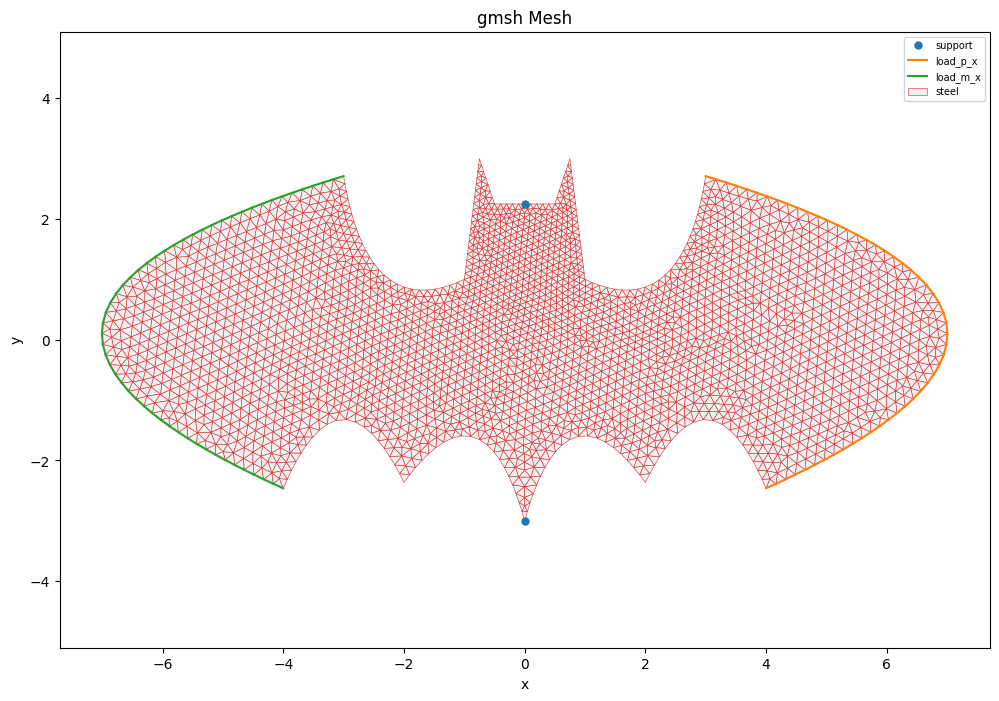

In [30]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [31]:
# build lumped nodal force vector
F_nodal = mesh.build_load_vector(load_dictionary)

# assemble to global vector
F_load = np.zeros(mesh.system_nDof)
for tag, f_vec in F_nodal.items():
    if tag in mesh.node_map:
        F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec
F_load[np.abs(F_load) < 1e-4] = 0.0

In [32]:
# # assemble consistent load vector
# F_load = np.zeros(mesh.system_nDof)
# for node in mesh.node_map.values():
#     F_load[node.idx] += node.nodalLoad  
# for elem in elements:
#     F_load[elem.idx] += elem.F_fe_global 
# F_load[np.abs(F_load) < 1e-4] = 0.0

## Opensees

In [33]:
# import openseespy.opensees as ops
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)

In [34]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [35]:
# Boundary conditions
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [36]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               Steel.E,
               Steel.nu,
               Steel.rho)

In [37]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

<Axes: >

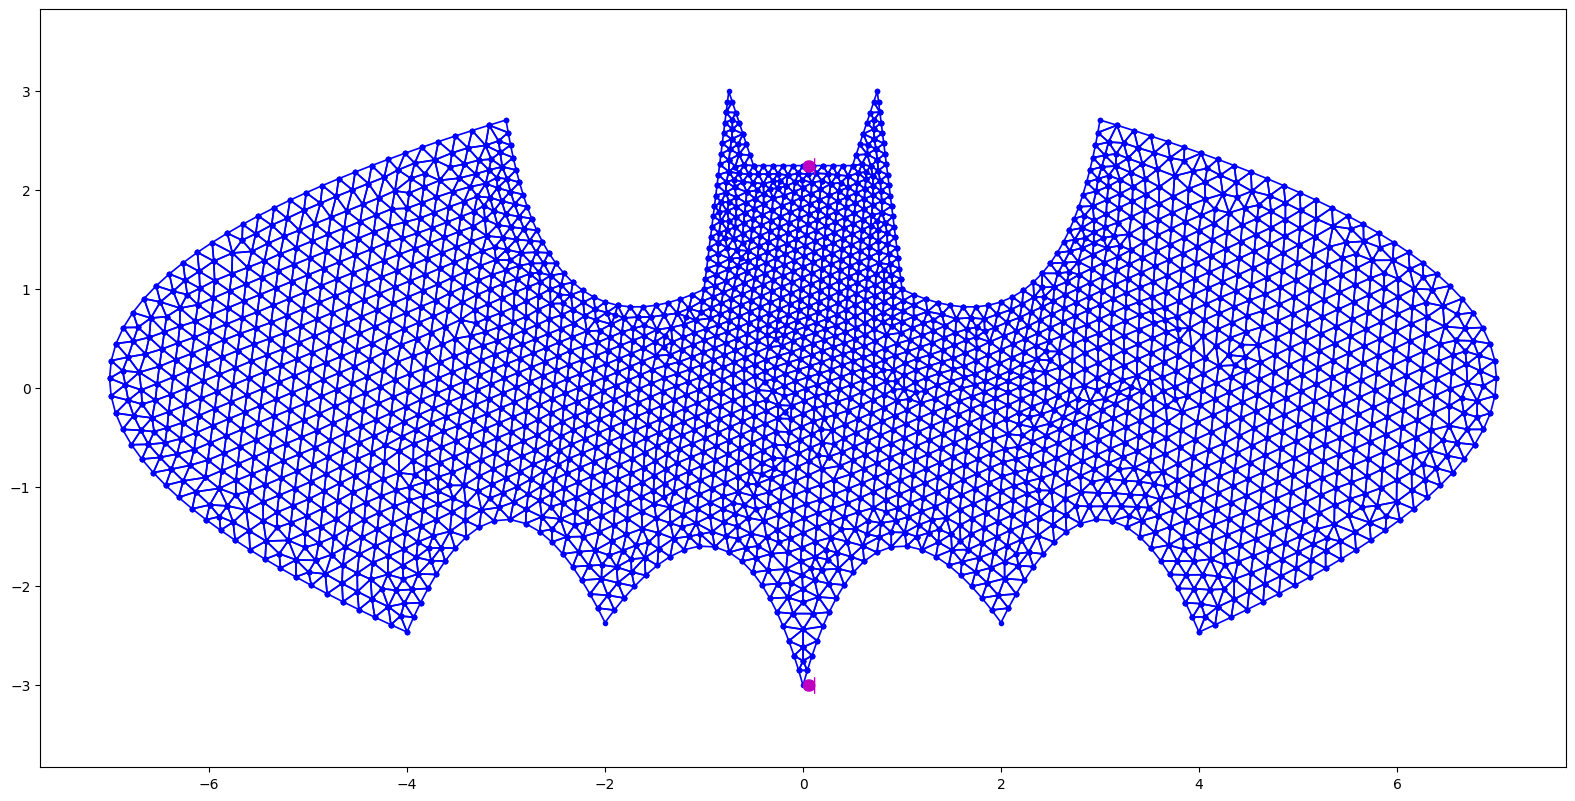

In [38]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [39]:
# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)

for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        ops.load(int(node.name), float(fx), float(fy))

In [40]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

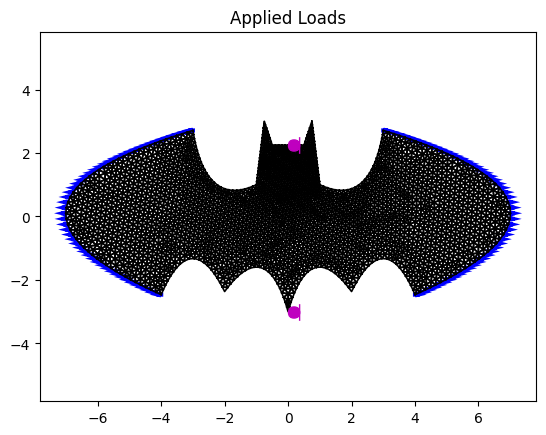

In [41]:
opsv.plot_loads_2d(sfac=0.1)
for txt in plt.gca().texts:
    txt.set_visible(False)
plt.title('Applied Loads')
plt.show()

10

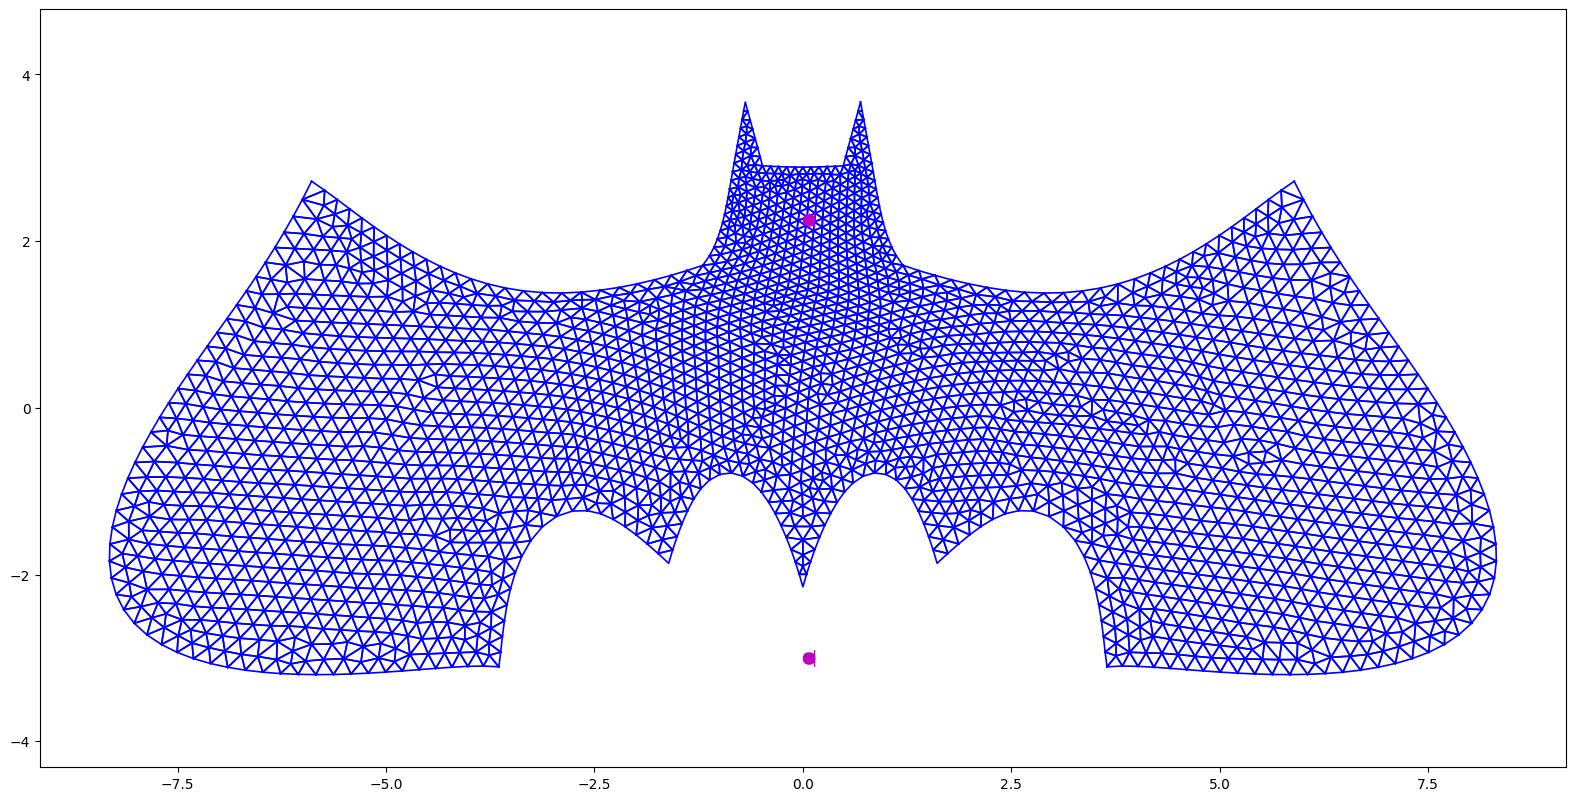

In [42]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'syy')

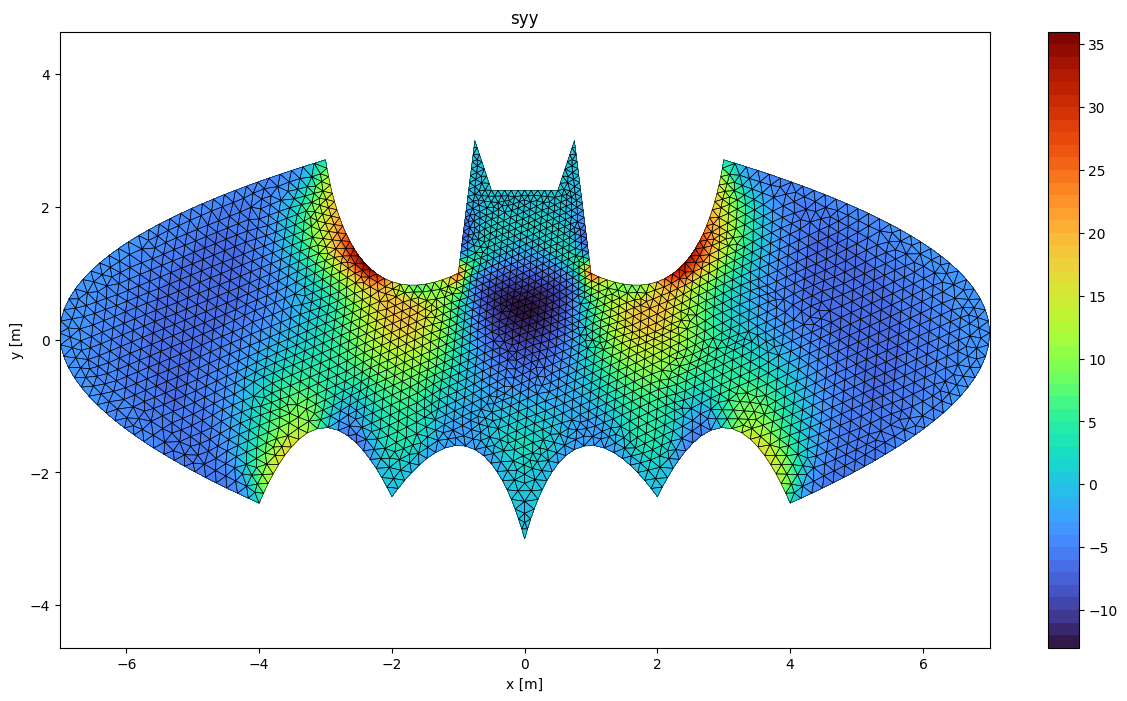

In [43]:
# jstr = 'sxx'
jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')

In [44]:
opensees2gmsh(
    output_file      = output_file,
    mesh             = mesh,
    ops              = ops,
    solid_group_name = 'steel',
    F_nodal          = F_nodal,
    disp_factor      = 50,
    material         = Steel,
    analysis_type    = 'planeStress',
    show_disp        = True,
    show_loads       = True,
    show_reactions   = True,
    show_stress      = True,
    show_strain      = True,
    show_vm          = True,
    show_averaged    = True,
)